
## **1. IMPORT CÁC THỨ VIỆN CẦN THIẾT**







In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Kết nổi với drive để lấy file csv về
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **2. LOAD DATASET**

In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/AI/titanic_train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/AI/titanic_test.csv")

In [ ]:
print("Dataset shape:", train_df.shape)



Dataset shape: (891, 12)


=> Dataset có tổng 891 hàng tương đương 891 khách hàng với 12 thuộc tính


# **3. DATA OVERVIEW**

3.1 XEM THÔNG TIN CỦA DATAFRAME

In [ ]:
#Xem các cột của dataframe train_df
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
#Xem các cột của dataframe test_df
test_df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
# train_df.drop("PassengerId",axis=1, inplace=True)
train_df.head()

# test_df.drop("PassengerId",axis=1, inplace=True)
# test_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
#Xem thông tin của dataframe train_df
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Kết luận: Dataframe train_df có các cột Age, Cabin, Embarked bị thiếu dữ liệu
> Các cột Pclass, Sex, Embarked dạng categorical



> Các cột Age, Fare , SibSp, Parch dạng numerical



In [ ]:
#Xem thông tin của dataframe test_df
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


Kết luận: Dataframe test_df có các cột Age, Fare, Cabin bị thiếu dữ liệu
> Các cột Pclass, Sex, Embarked dạng categorical



> Các cột Age, Fare , SibSp, Parch dạng numerical

 3.2 CHUYỂN ĐỔI DỮ LIỆU CÁC CỘT




In [ ]:
#Chuyển đổi các cột thành kiểu category của hai dataframe
features= ["Pclass","Sex","Embarked"]
def convert_cat(df,features):
  for feature in features:
    df[feature]= df[feature].astype("category")
convert_cat(train_df,features)
convert_cat(test_df,features)
train_df.info()
test_df.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
dtypes: category(3), float64(2), int64(4), object(3)
memory usage: 65.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  418 non-

3.3 THỐNG KÊ GIÁ TRỊ LÚC CHƯA ĐỦ DỮ LIỆU

In [ ]:
#Dành cho các cột Numerical của train_df
train_df.describe()

,PassengerId,Survived,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
#Dành cho các cột Categorical của train_df
train_df.describe(include="category")

,Pclass,Sex,Embarked
count,891,891,889
unique,3,2,3
top,3,male,S
freq,491,577,644


# **4.	PREPROCESSING VALUES ANALYSIS**

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder






4.1 TÍNH SỐ LƯỢNG / PHẦN TRĂM VALUES BỊ THIẾU Ở CÁC CỘT CATEGORICAL VÀ NUMERICAL


In [ ]:
num_features=["Age","Fare"]
cat_features =["Pclass","Sex","Embarked","SibSp","Parch"]
feature_cols = num_features + cat_features
def display_missing(df,feature_cols):
  n_rows = len(df)
  for col in feature_cols:
    missing_count= df[col].isnull().sum()
    missing_rating = (missing_count / n_rows) * 100
    if missing_count > 0:
      print(f"Cột {col} có {missing_count} dữ liệu bị thiếu tương đương với {missing_rating:.2f}%")
display_missing(train_df,feature_cols)
display_missing(test_df,feature_cols)

Cột Age có 177 dữ liệu bị thiếu tương đương với 19.87%
Cột Embarked có 2 dữ liệu bị thiếu tương đương với 0.22%
Cột Age có 86 dữ liệu bị thiếu tương đương với 20.57%
Cột Fare có 1 dữ liệu bị thiếu tương đương với 0.24%


4.2 TRỰC QUAN HÓA MẤT MÁT DỮ LIỆU


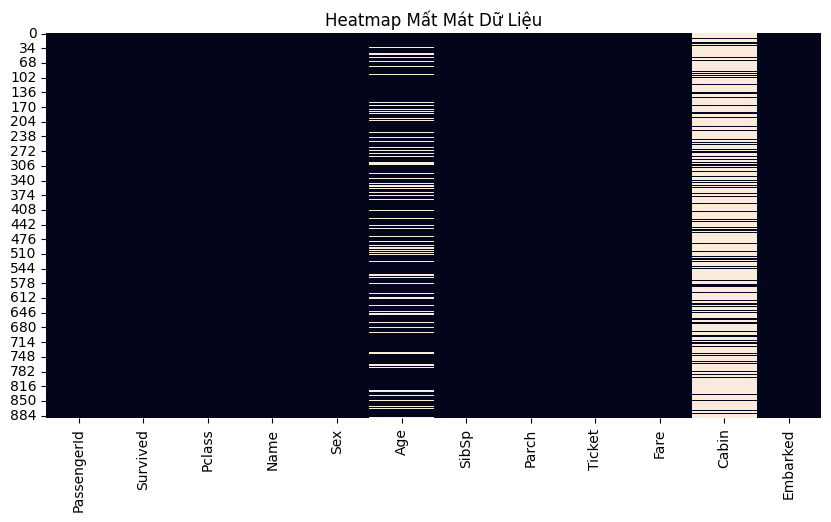

In [ ]:
#Dataframe train_df
plt.figure(figsize=(10,5))
sns.heatmap(train_df.isnull(), cbar=False)
plt.title("Heatmap Mất Mát Dữ Liệu")
plt.show()

4.3 CHECK DỮ LIỆU TRÙNG LẮP

In [ ]:
train_df.duplicated().sum()

np.int64(0)

=> Dataframe train_df không có dữ liệu trùng lắp

4.4 CHECK OUTLIERS CỦA CÁC CỘT NUMERICAL

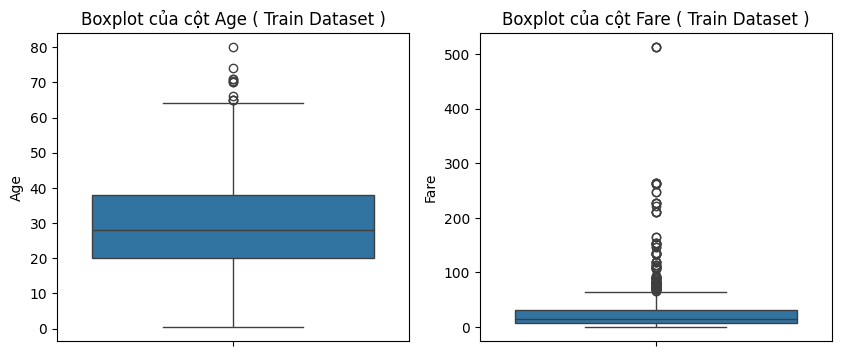

In [ ]:
num_features = ['Age','Fare']

def plot_boxplots(df, features,name):
    plt.figure(figsize=(10,4))
    pos = 1
    for row in range(1):
        for col in range(len(features)):
            plt.subplot(1, len(features), pos)
            feature = features[col]
            sns.boxplot(y=df[feature])
            plt.title(f"Boxplot của cột {feature} ( {name} )")
            pos += 1
    plt.show()
plot_boxplots(train_df, num_features, "Train Dataset")

4.5 CHECK IMPUTATION STRATEGY CỦA AGE VÀ FARE

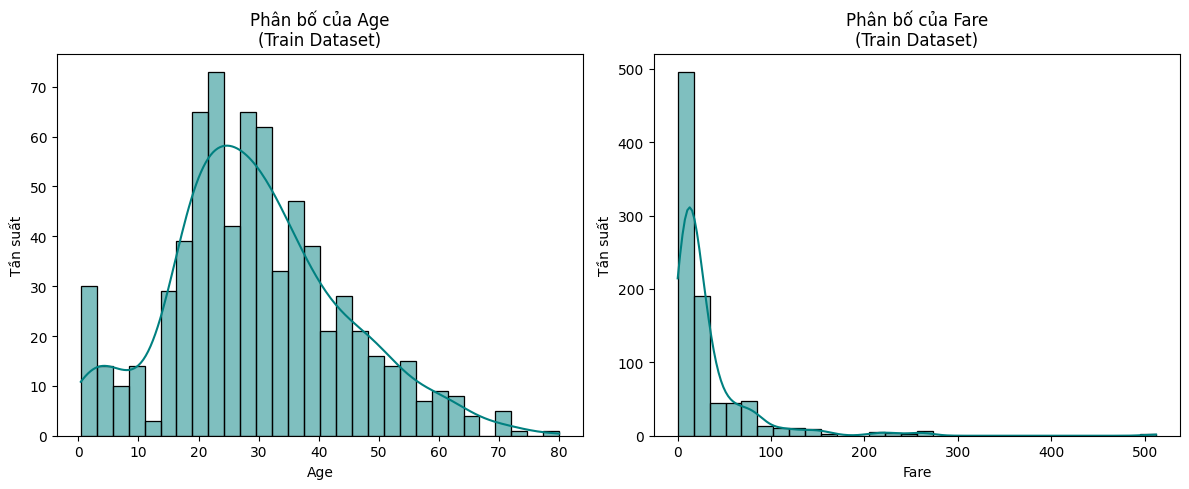

            Age       Fare
mean  29.699118  32.204208
50%   28.000000  14.454200


In [ ]:
num_features =['Age','Fare']
def hisplot_features(df, features, name):

    fig, axes = plt.subplots(1, len(features), figsize=(len(features) * 6, 5))


    if len(features) == 1: axes = [axes]

    for i, feature in enumerate(features):
        sns.histplot(data=df, x=feature, bins=30, kde=True, ax=axes[i], color='teal')
        axes[i].set_title(f"Phân bố của {feature}\n({name})", fontsize=12)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel("Tần suất")

    plt.tight_layout()
    plt.show()

hisplot_features(train_df, num_features, "Train Dataset")

# Thống kê mô tả để so sánh Mean và Median
print(train_df[['Age', 'Fare']].describe().loc[['mean', '50%']])

Đối với cột Fare:


>  Con số Mean (32.2) cao gấp hơn 2 lần so với Median (14.4) + việc biểu đồ bị lệch sang phải rất nhiều nên chứng tỏ một nhóm hành khách mua vé với giá cao (outliers), kéo con số trung bình lên rất cao.Nếu ta điền số $32.2$ vào những người bị thiếu dữ liệu, ta sẽ biến các hành khách đó thành người giàu, trong khi thực tế đại đa số trả dưới 14.45


> KẾT LUẬN: Dùng Median (14.45) sẽ phản ánh đúng thực tế của đại đa số hành khách nhất

Đối với cột Age:

> Tuy con số không chênh lệch nhiều, nhưng Mean (29.7) vẫn lớn hơn Median (28.0) + biểu đồ vẫn xuất hiện một số chấm đen ở phía tay phải. Có một số hành khách lớn tuổi (như các cụ già 70-80 tuổi) đang kéo cái ngưỡng trung bình lên


> KẾT LUẬN: Dùng Median sẽ phản ánh đúng độ tuổi trung bình của tất cả hành khách hơn





Kết luận: Trong thống kê, khi dữ liệu không chuẩn (không đối xứng hoàn hảo), Median luôn là đại diện tốt hơn cho "trung tâm" của tập dữ liệu vì nó không bị ảnh hưởng bởi những cụ già 80 tuổi hay các em bé sơ sinh.

4.6 CHECK IMPUTATION STRATEGY CỦA EMBARKED

/tmp/ipykernel_370/2750134151.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='Embarked', palette='viridis')


Giá trị phổ biến nhất là S với 644 lần xuất hiện.


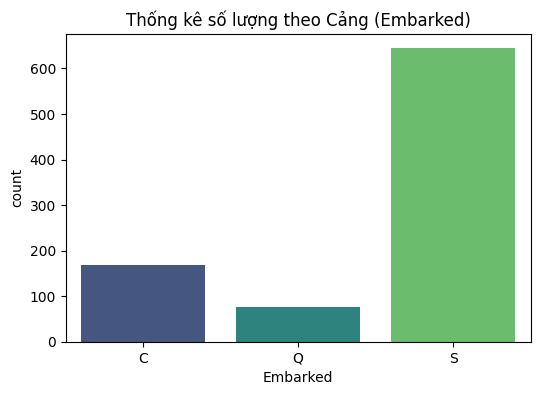

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='Embarked', palette='viridis')
mode_embarked = train_df['Embarked'].mode()[0]
count_mode = (train_df['Embarked'] == mode_embarked).sum()
print(f"Giá trị phổ biến nhất là {mode_embarked} với {count_mode} lần xuất hiện.")
plt.title('Thống kê số lượng theo Cảng (Embarked)')
plt.show()



 Biểu đồ  cho thấy cảng "S" chiếm đa số tuyệt đối. Vì vậy, việc đoán một người thiếu thông tin cũng lên tàu tại cảng "S" có xác suất đúng cao nhất


> KẾT LUẬN: Dùng most_frequent sẽ hợp lý nhất





4.7 CHECK IMPUTATION STRATEGY CỦA SEX

Tỉ lệ giới tính trên tàu:
Sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64


/tmp/ipykernel_370/2428716022.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='Sex', palette='pastel')


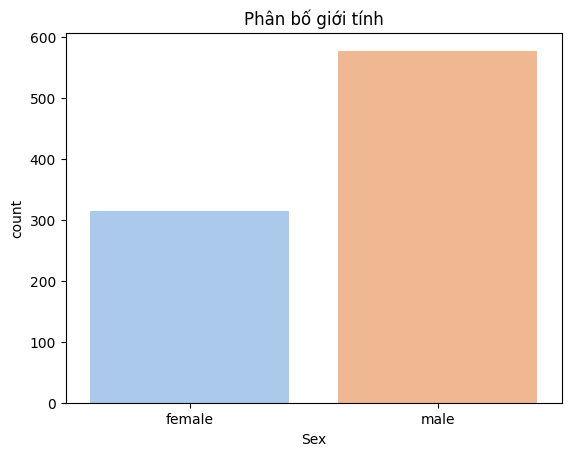

In [ ]:
# Kiểm tra tỉ lệ Nam/Nữ
sex_counts = train_df['Sex'].value_counts(normalize=True) * 100
print("Tỉ lệ giới tính trên tàu:")
print(sex_counts)

sns.countplot(data=train_df, x='Sex', palette='pastel')
plt.title('Phân bố giới tính')
plt.show()

Tỉ lệ nam giới xuất hiện trên tàu nhiều hơn hẳn cho với nữ


> KẾT LUẬN: Dùng most_frequent sẽ hợp lý nhất



4.4 SKLEARN PIPELINE



In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder,OrdinalEncoder

#Điền thiếu và Scaling cho nhóm Numerical ( Age + Fare)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

#Điền thiếu và Encoding cho Embarked
embarked_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False,dtype=int))
])
#Điền thiếu và Encoding cho Sex
sex_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[['female', 'male']],dtype=int))
])
# Tổng hợp pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('n', num_transformer, ['Age', 'Fare']),
        ('c', embarked_transformer, ['Embarked']),
        ('s', sex_transformer, ['Sex'])
    ],
    verbose_feature_names_out=False,
    #Giữ lại các cột không xử lý (Sex, Pclass, SibSp,...)
    remainder='drop'
)

In [ ]:
# Thiết lập Pipeline trả về DataFrame
preprocessor.set_output(transform="pandas")

# Bây giờ fit_transform sẽ ra ngay DataFrame có tên cột đầy đủ
train_df_check = preprocessor.fit_transform(train_df)

display(train_df_check .head())

,Age,Fare,Embarked_Q,Embarked_S,Sex
0,0.271174,0.014151,0,1,1
1,0.472229,0.139136,0,0,0
2,0.321438,0.015469,0,1,0
3,0.434531,0.103644,0,1,0
4,0.434531,0.015713,0,1,1


In [ ]:
# Xóa cột Cabin gốc để tránh làm loãng dữ liệu
# train_df.drop(columns=['Cabin'], inplace=True)

# **5.UNIVARIATE ANALYSIS**

5.1 CÁC CỘT CATEGORICAL

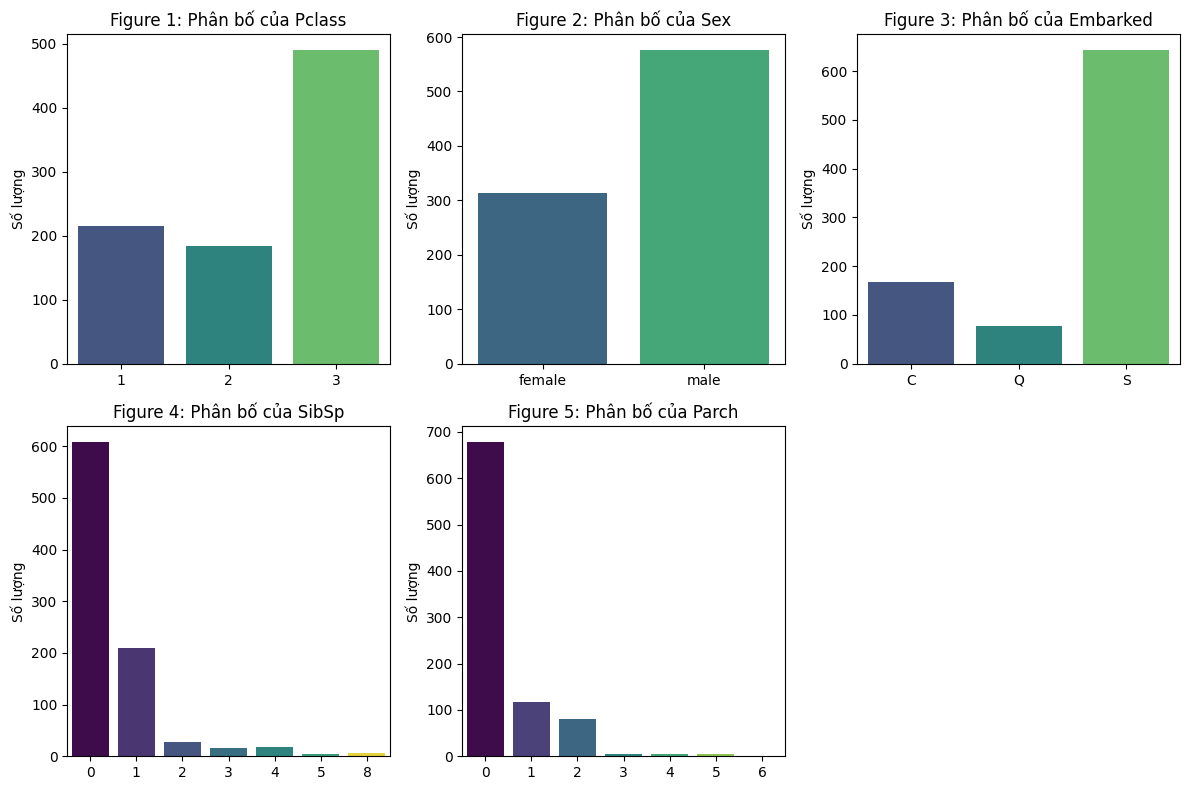

In [ ]:
import math
cate_features = ['Pclass', 'Sex', 'Embarked', 'SibSp', 'Parch']
n_cols = 3
n_rows = math.ceil(len(cate_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(cate_features):
    sns.countplot(data=train_df, x=feature, hue=feature, ax=axes[i], palette='viridis', legend=False)
    axes[i].set_title(f"Figure {i+1}: Phân bố của {feature}", fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Số lượng")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

NHẬN XÉT:


> Biểu đồ cho thấy hành khách hạng 3 (Pclass = 3) chiếm tỷ lệ lớn nhất trong dataset, khoảng hơn một nửa tổng số hành khách, trong khi hạng 1 và hạng 2 có số lượng thấp hơn đáng kể. Điều này phản ánh rằng phần lớn hành khách trên tàu Titanic thuộc tầng lớp trung lưu hoặc lao động với giá vé thấp


> Biểu đồ phân bố giới tính cho thấy số lượng hành khách nam nhiều hơn nữ khá rõ rệt, chiếm khoảng hai phần ba tổng số hành khách trong dataset. Điều này phản ánh đặc điểm xã hội của thời kỳ đó khi nam giới thường chiếm phần lớn trong các chuyến đi dài hoặc di cư


> Biểu đồ cho thấy phần lớn hành khách lên tàu tại cảng Southampton (S), chiếm tỷ lệ áp đảo so với hai cảng còn lại là Cherbourg (C) và Queenstown (Q). Điều này phù hợp với lịch sử khi Titanic khởi hành từ Southampton nên số hành khách tại đây nhiều nhất


> Biểu đồ cho thấy đa số hành khách đi một mình, trong khi các gia đình lớn trên tàu là tương đối ít


> Biểu đồ cho thấy phần lớn hành khách không đi cùng gia đình trực hệ trên tàu









5.2 CÁC CỘT NUMERICAL


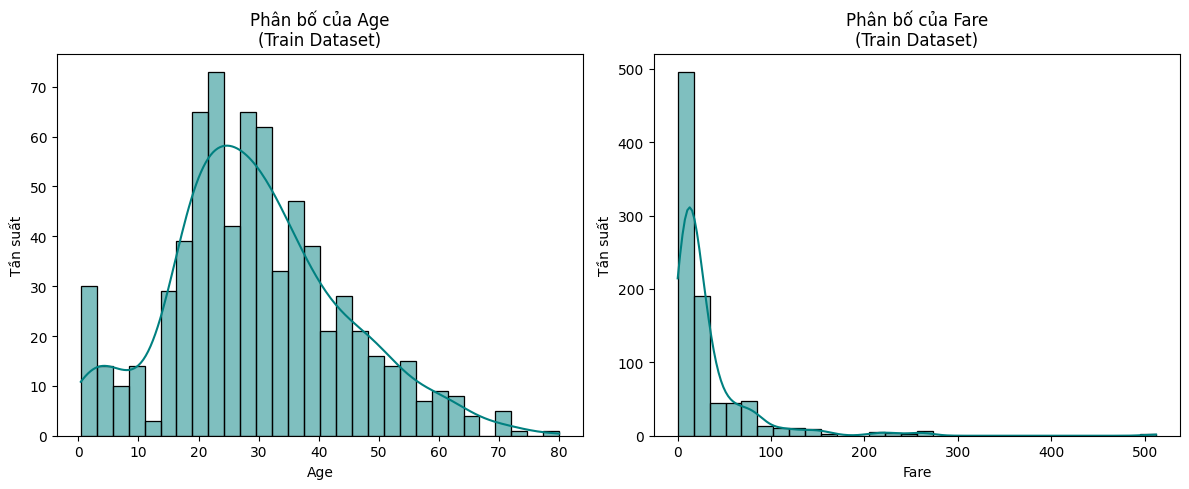

In [ ]:
num_features =['Age','Fare']
def hisplot_features(df, features, name):

    fig, axes = plt.subplots(1, len(features), figsize=(len(features) * 6, 5))


    if len(features) == 1: axes = [axes]

    for i, feature in enumerate(features):
        sns.histplot(data=df, x=feature, bins=30, kde=True, ax=axes[i], color='teal')
        axes[i].set_title(f"Phân bố của {feature}\n({name})", fontsize=12)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel("Tần suất")

    plt.tight_layout()
    plt.show()

hisplot_features(train_df, num_features, "Train Dataset")


NHẬN XÉT:

> Về Age: cho thấy độ tuổi hành khách tập trung chủ yếu trong khoảng 20–40 tuổi, với đỉnh phân bố khoảng 30 tuổi, cho thấy phần lớn hành khách là người trưởng thành trẻ. Số lượng trẻ em và người cao tuổi khá ít, và số người giảm dần khi tuổi tăng. Phân bố Age hơi lệch phải, cho thấy vẫn tồn tại một số hành khách lớn tuổi nhưng không nhiều


> Về Fare: có dạng lệch phải, trong đó phần lớn hành khách có giá vé thấp (dưới khoảng 50), trong khi chỉ có một số ít hành khách trả giá vé rất cao, tạo thành positive skewness. Điều này phản ánh sự chênh lệch lớn về điều kiện kinh tế giữa các hành khách trên tàu




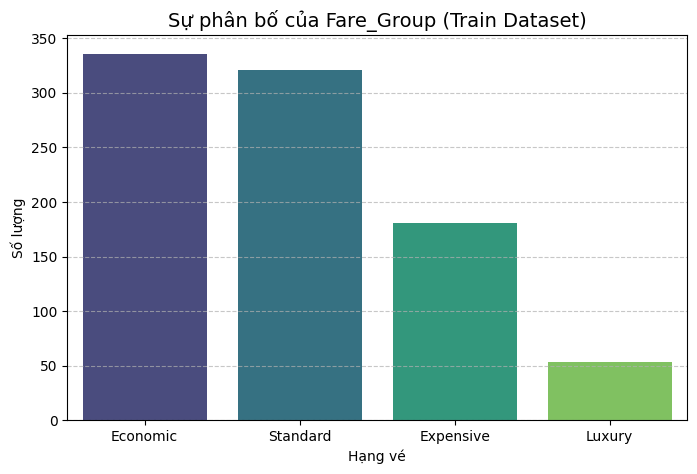

In [ ]:
def preprocess_fare(df):
    df_copy = df.copy()
    df_copy["Fare_Group"] = pd.cut(
        df_copy["Fare"],
        bins=[-1, 10, 30, 100, 600], # Bắt đầu từ -1 để bao gồm cả giá trị 0
        labels=["Economic", "Standard", "Expensive", "Luxury"],
        include_lowest=True
    )
    return df_copy

def plot_fare_group(df, name):
    if "Fare_Group" not in df.columns:
        print("Cột Fare_Group chưa tồn tại!")
        return

    plt.figure(figsize=(8, 5))

    order = ["Economic", "Standard", "Expensive", "Luxury"]

    sns.countplot(data=df, x="Fare_Group", order=order, palette="viridis", hue="Fare_Group", legend=False)

    plt.title(f"Sự phân bố của Fare_Group ({name})", fontsize=14)
    plt.xlabel("Hạng vé")
    plt.ylabel("Số lượng")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Sử dụng
train_df = preprocess_fare(train_df)
plot_fare_group(train_df, "Train Dataset")

### Nhận xét về sự phân bổ của Fare_Group

Biểu đồ cột thể hiện số lượng hành khách theo 4 nhóm giá vé đã được phân loại. Chúng ta có thể rút ra các quan sát quan trọng sau:

* **Sự chiếm ưu thế của nhóm giá rẻ:** Hai nhóm **Economic** và **Standard** chiếm tỉ trọng áp đảo trong tổng số hành khách (khoảng hơn 650 người). Điều này cho thấy đa số hành khách trên tàu là tầng lớp lao động hoặc bình dân.
* **Cấu trúc hình tháp:** Số lượng hành khách giảm dần khi mức giá vé tăng lên. Đây là mô hình kinh tế điển hình: số lượng người có khả năng chi trả cho các mức vé **Expensive** và đặc biệt là **Luxury** (chỉ khoảng hơn 50 người) là rất ít.



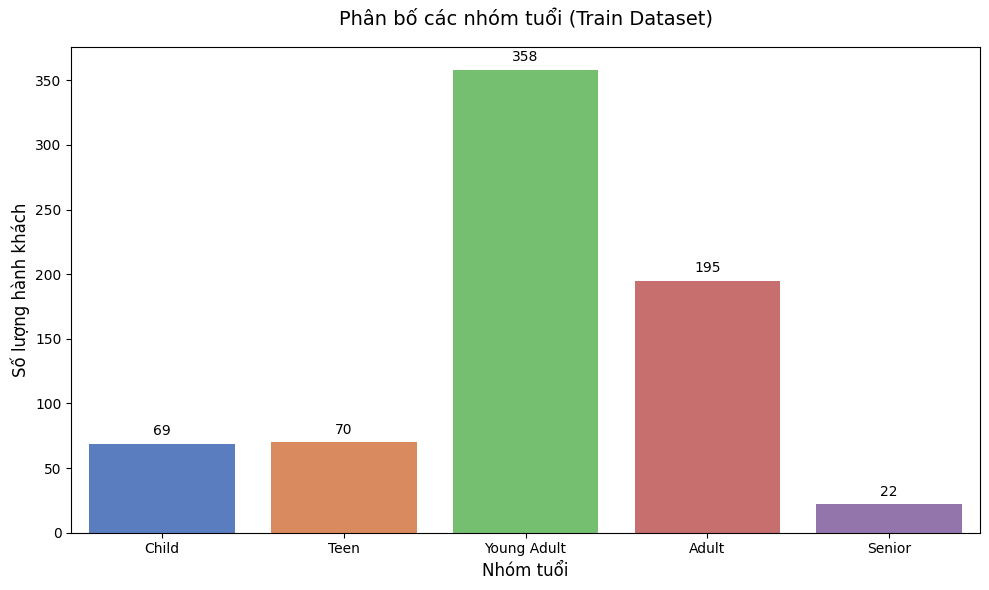

In [ ]:
def plot_age_distribution(df, name):

    temp_df = df.copy()


    bins = [0, 12, 18, 35, 60, 100]
    labels = ["Child", "Teen", "Young Adult", "Adult", "Senior"]

    temp_df["Age_group"] = pd.cut(
        temp_df["Age"],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=temp_df,
        x="Age_group",
        hue="Age_group",
        palette="muted",
        order=labels,
        legend=False
    )

    plt.title(f"Phân bố các nhóm tuổi ({name})", fontsize=14, pad=15)
    plt.xlabel("Nhóm tuổi", fontsize=12)
    plt.ylabel("Số lượng hành khách", fontsize=12)

    # Thêm số lượng cụ thể trên đầu mỗi cột (tùy chọn nhưng rất hữu ích)
    for p in plt.gca().patches:
        plt.gca().annotate(f'{int(p.get_height())}',
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='center',
                           xytext=(0, 9),
                           textcoords='offset points')

    plt.tight_layout()
    plt.show()

plot_age_distribution(train_df, "Train Dataset")

NHẬN XÉT: Sau khi phân chia độ tuổi thành các nhóm Child, Teen, Young Adult, Adult và Senior, có thể thấy nhóm Young Adult (18–35 tuổi) chiếm số lượng lớn nhất, vượt trội so với các nhóm còn lại. Nhóm Adult (35–60 tuổi) đứng thứ hai nhưng thấp hơn khá nhiều so với Young Adult. Trong khi đó, các nhóm Child, Teen và đặc biệt là Senior có số lượng khá ít. Điều này cho thấy phần lớn hành khách trên tàu là những người trong độ tuổi trưởng thành trẻ

# **6. Bivariate Analysis**

6.1 CÁC CỘT CATEGORICAL

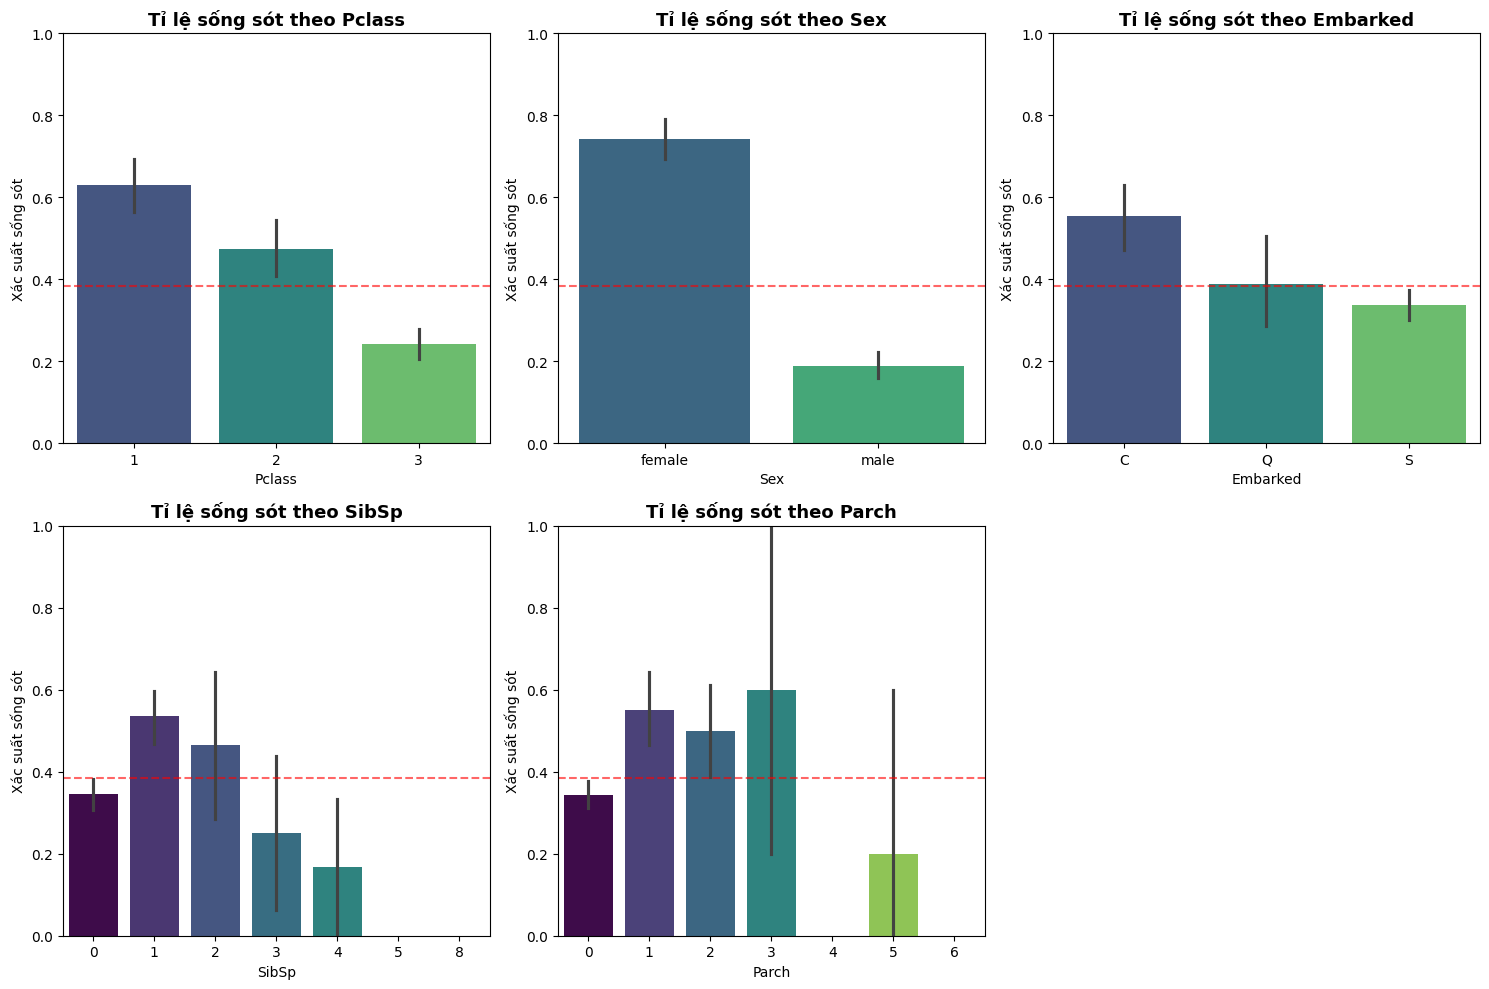

In [ ]:
def plot_survival_analysis(df, cols):
    n_cols = 3
    n_rows = math.ceil(len(cols) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
    axes = axes.flatten()

    # Tính tỉ lệ sống sót trung bình toàn tập dữ liệu để làm mốc so sánh
    overall_survival_rate = df['Survived'].mean()

    for i, col in enumerate(cols):
        # Vẽ barplot - Seaborn tự tính xác suất sống sót và vẽ thanh sai số (error bar)
        sns.barplot(data=df, x=col, y='Survived', ax=axes[i], palette='viridis', hue=col, legend=False)

        # Thêm đường kẻ ngang thể hiện tỉ lệ sống sót trung bình chung
        axes[i].axhline(overall_survival_rate, color='red', linestyle='--', alpha=0.6, label='Avg Survival Rate')

        axes[i].set_title(f'Tỉ lệ sống sót theo {col}', fontsize=13, fontweight='bold')
        axes[i].set_ylabel('Xác suất sống sót')
        axes[i].set_ylim(0, 1) # Luôn để trục Y từ 0 đến 1 (100%)

    # Ẩn các ô thừa
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

cols = ["Pclass", "Sex", "Embarked", "SibSp", "Parch"]
plot_survival_analysis(train_df, cols)

## Nhận xét kết quả phân tích Bivariate (Features vs Survived)

### 1. Cái nhìn tổng quan

Tỉ lệ sống sót trung bình của hành khách trong tập dữ liệu là khoảng **38%** (đường đỏ nét đứt). Các biến như `Sex`, `Pclass` thể hiện sự phân hóa cực kỳ rõ rệt, trong khi các biến gia đình (`SibSp`, `Parch`) cho thấy những xu hướng phức tạp hơn.

### 2. Phân tích chi tiết các biến

* **Giới tính (Sex):** Đây là đặc trưng có khả năng phân loại mạnh nhất. Hành khách **Nữ (Female)** có tỉ lệ sống sót cao vọt (74%), gấp gần 4 lần so với **Nam giới (Male)** (~19%). Điều này phù hợp với quy tắc ưu tiên "Phụ nữ và trẻ em" trong thảm họa.
* **Hạng vé (Pclass):** Có sự phân cấp xã hội rõ rệt trong khả năng sinh tồn. Hành khách **Hạng 1** có xác suất sống sót cao nhất (>60%), tiếp theo là Hạng 2 và thấp nhất là **Hạng 3** (chỉ khoảng 24%).
* **Cảng lên tàu (Embarked):** Hành khách lên tàu tại cảng **C (Cherbourg)** có tỉ lệ sống sót cao nhất (~55%), vượt xa mức trung bình. Cảng S có tỉ lệ thấp nhất.
* **Deck** **'U'** có tỉ lệ sống sót thấp nhất (~30%), nằm dưới mức trung bình (đường đỏ).
* **Ý nghĩa:** Khoảng tin cậy của cột 'U' rất ngắn, cho thấy kích thước mẫu cực lớn. Điều này khẳng định dữ liệu Cabin bị thiếu chủ yếu tập trung ở hành khách Hạng 3. Việc không có số phòng là một chỉ báo mạnh cho thấy hành khách ở vị trí khó tiếp cận thuyền cứu hộ.
* **Nhận xét:** Các tầng **B, D, E** và **C** đều có tỉ lệ sống sót rất cao (từ **60% đến gần 80%**).
* **Giải thích:** Đây là những tầng nằm ở phía trên của con tàu, chủ yếu dành cho hành khách Hạng 1. Vị trí địa lý gần boong tàu giúp họ thoát hiểm nhanh hơn khi thảm họa xảy ra.
> *Lưu ý:* Cần kiểm tra xem có phải hành khách giàu (Pclass 1) tập trung nhiều ở cảng C hay không.


* **Mối quan hệ gia đình (SibSp & Parch):** * Hành khách đi theo **nhóm nhỏ** (1-2 người thân đối với `SibSp` hoặc 1-3 người đối với `Parch`) có cơ hội sống sót cao hơn so với người đi một mình hoặc đi theo gia đình quá đông.
* Các nhóm có gia đình cực đông (SibSp > 4 hoặc Parch > 4) có tỉ lệ sống sót rất thấp hoặc bằng 0.
* **Độ tin cậy:** Các vạch đen (sai số) ở nhóm `Parch = 3` hoặc `Parch = 5` rất dài, cho thấy kích thước mẫu ở các nhóm này rất nhỏ, kết quả về tỉ lệ không mang tính đại diện cao.



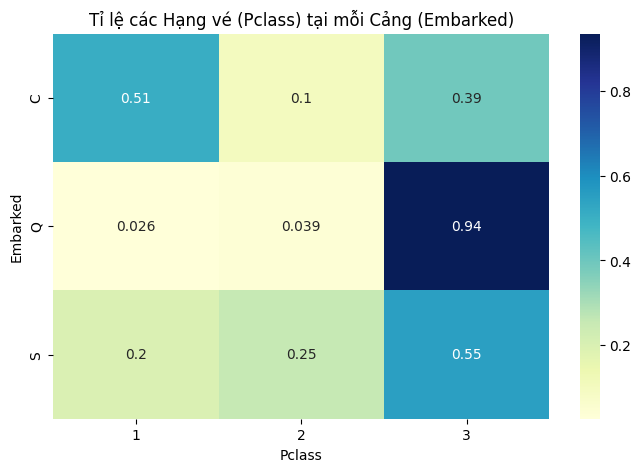

In [ ]:
# Biểu đồ Heatmap để xem sự tương quan giữa Cảng và Hạng vé
embarked_pclass = pd.crosstab(train_df['Embarked'], train_df['Pclass'], normalize='index')

plt.figure(figsize=(8, 5))
sns.heatmap(embarked_pclass, annot=True, cmap='YlGnBu')
plt.title('Tỉ lệ các Hạng vé (Pclass) tại mỗi Cảng (Embarked)')
plt.show()

/tmp/ipykernel_370/1493924566.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


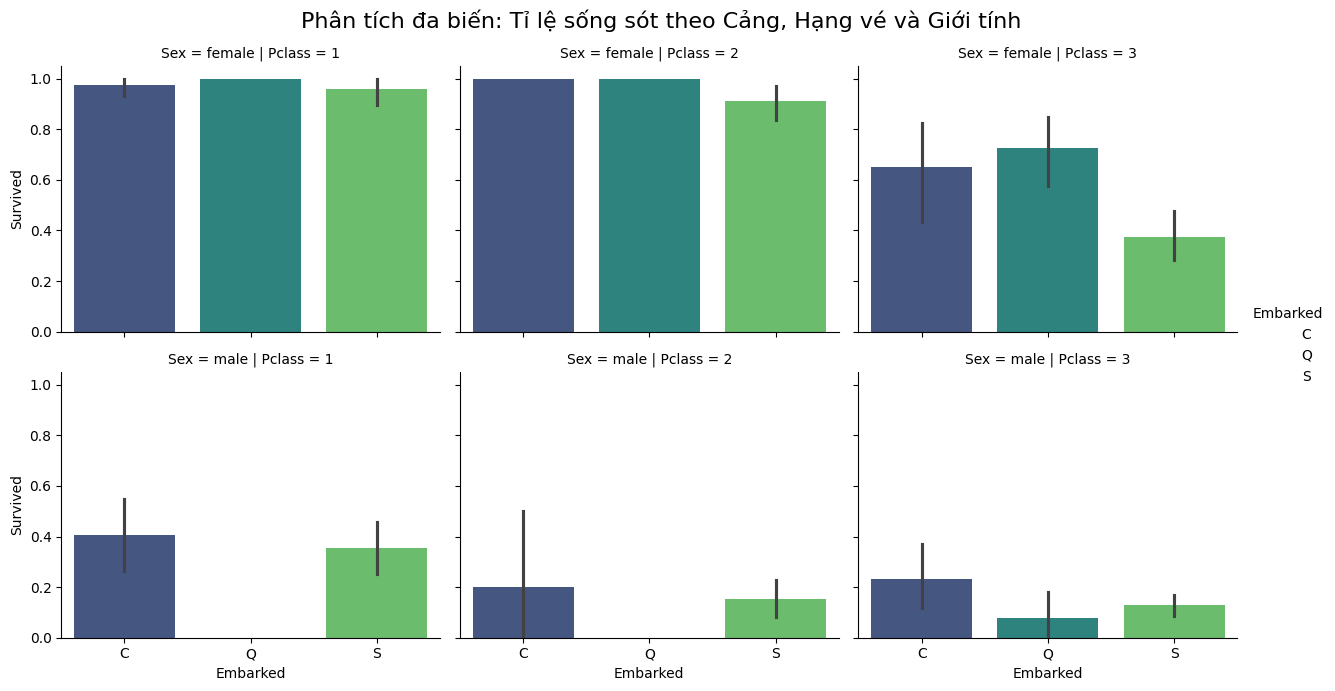

In [ ]:
# kind='bar' tương đương với việc gọi barplot
sns.catplot(
    data=train_df,
    x='Embarked',
    y='Survived',
    col='Pclass',
    row='Sex',
    kind='bar',
    palette='viridis',
    height=3.5,
    aspect=1.2
)

plt.subplots_adjust(top=0.9)
plt.suptitle('Phân tích đa biến: Tỉ lệ sống sót theo Cảng, Hạng vé và Giới tính', fontsize=16)
plt.show()

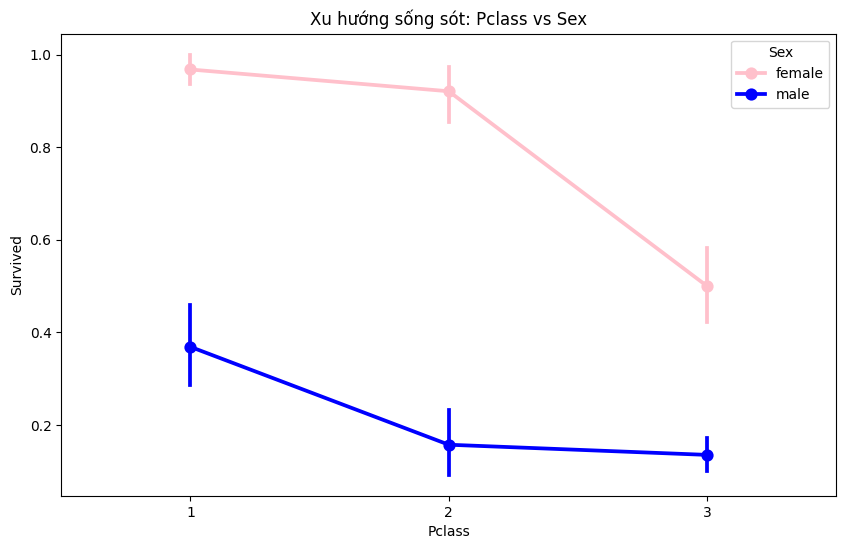

In [ ]:
plt.figure(figsize=(10, 6))
sns.pointplot(data=train_df, x='Pclass', y='Survived', hue='Sex', palette={'male': 'blue', 'female': 'pink'})
plt.title('Xu hướng sống sót: Pclass vs Sex')
plt.show()

### Phân tích Đa biến và Tương quan (Multivariate & Correlation Analysis)

Dựa trên các biểu đồ phân tích sự tương tác giữa các đặc trưng (`Sex`, `Pclass`, `Embarked`) và biến mục tiêu (`Survived`), chúng ta có các nhận định quan trọng sau:

#### 1. Mối tương quan giữa Cảng lên tàu (Embarked) và Hạng vé (Pclass)

* **Cảng C (Cherbourg):** Có tỉ lệ hành khách **Hạng 1 cao nhất (~51%)**. Điều này giải thích tại sao trong các phân tích đơn biến, hành khách cảng C luôn có tỉ lệ sống sót cao vượt trội.
* **Cảng Q (Queenstown):** Gần như toàn bộ hành khách là **Hạng 3 (~94%)**.
* **Kết luận:** Đặc trưng `Embarked` có mối tương quan thuận với mức độ giàu có (`Pclass`). Tỉ lệ sống sót cao ở một số cảng không phải do vị trí địa lý mà do phân lớp xã hội của hành khách tại cảng đó.

#### 2. Tác động tổng hợp của Giới tính, Hạng vé và Cảng lên tàu

* **Đặc quyền của Phụ nữ Hạng cao:** Phụ nữ thuộc **Hạng 1 và Hạng 2** có tỉ lệ sống sót gần như tuyệt đối (**~100%**) bất kể họ lên tàu ở cảng nào.
* **Sự khác biệt ở Hạng 3:** Phụ nữ Hạng 3 có tỉ lệ sống sót thấp hơn nhiều và biến động mạnh theo cảng (Cảng C và Q có tỉ lệ sống sót cao hơn cảng S).
* **Nam giới và Hạng vé:** Ngay cả nam giới ở Hạng 1 (giàu nhất) cũng có tỉ lệ sống sót thấp hơn nhiều so với phụ nữ ở Hạng 3 (nghèo nhất). Điều này khẳng định yếu tố **Giới tính (Sex)** có trọng số cao hơn **Hạng vé (Pclass)** trong mô hình dự đoán.

#### 3. Xu hướng sống sót (Interaction Plot)

* **Khoảng cách giới tính:** Đường biểu diễn của Nữ (Female) luôn nằm cao hơn hẳn Nam (Male), cho thấy giới tính là đặc trưng phân loại mạnh nhất.
* **Sự sụt giảm theo Hạng vé:** * Đối với **Nữ**: Tỉ lệ sống sót duy trì ở mức cao tại Hạng 1 và 2, nhưng **giảm mạnh** khi xuống Hạng 3.
* Đối với **Nam**: Cơ hội sống sót giảm đều và rõ rệt nhất ngay khi rời khỏi Hạng 1. Hạng 2 và Hạng 3 đối với nam giới đều là những nhóm có rủi ro cực cao.


* **Kết luận:** `Pclass 3` là nhóm chịu ảnh hưởng nặng nề nhất trong thảm họa, đặc biệt là nam giới.


6.2 CÁC CỘT NUMERICAL

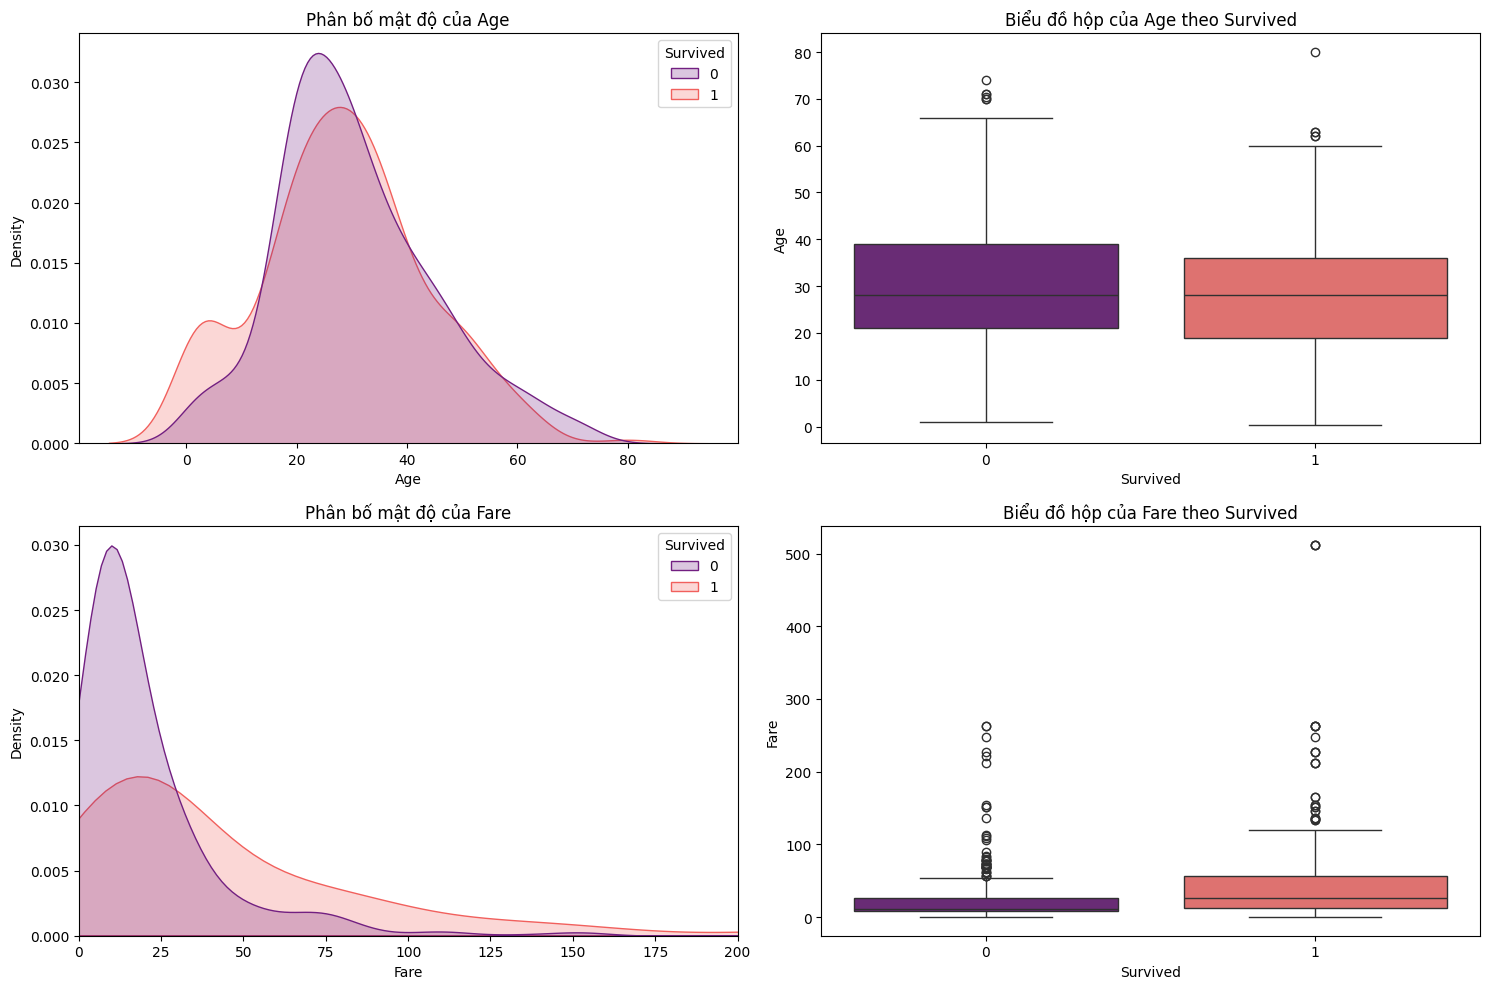

In [ ]:
def plot_numerical_features(df, features):
    # Mỗi feature sẽ có 1 dòng, gồm 2 cột: KDE Plot và Box Plot
    fig, axes = plt.subplots(len(features), 2, figsize=(15, len(features) * 5))

    for i, feature in enumerate(features):
        # 1. Vẽ KDE Plot (Làm mịn histogram)
        sns.kdeplot(data=df, x=feature, hue="Survived", fill=True, ax=axes[i, 0], palette="magma", common_norm=False)
        axes[i, 0].set_title(f"Phân bố mật độ của {feature}")

        # 2. Vẽ Boxplot (Xem giá trị ngoại lai và trung vị)
        sns.boxplot(data=df, x="Survived", y=feature, ax=axes[i, 1], palette="magma", hue="Survived", legend=False)
        axes[i, 1].set_title(f"Biểu đồ hộp của {feature} theo Survived")

        # Xử lý riêng cho Fare vì nó quá lệch
        if feature == 'Fare':
            axes[i, 0].set_xlim(0, 200) # Giới hạn lại để nhìn rõ vùng 0-200$

    plt.tight_layout()
    plt.show()

plot_numerical_features(train_df, ['Age', 'Fare'])

### 1. Phân tích biến Tuổi (Age)

* **KDE Plot (Trái):** Nhìn vào phần **đầu vách trái (tầm 0 - 10 tuổi)**, bạn sẽ thấy đường màu hồng (Survived=1) vọt lên cao hơn hẳn đường màu tím.
* **Insight:** Điều này khẳng định trẻ em có cơ hội sống sót cao vượt trội. Đây là một "đặc trưng" (feature) cực tốt cho model.
* **Vùng 20-40 tuổi:** Hai đường chồng lấp lên nhau rất nhiều, nghĩa là ở độ tuổi trưởng thành, yếu tố tuổi tác không còn giúp phân loại "sống/chết" mạnh mẽ bằng các yếu tố khác.


* **Box Plot (Phải):** Trung vị (vạch ngang ở giữa hộp) của hai nhóm gần như bằng nhau (khoảng 28-30 tuổi).
* **Insight:** Điều này cho thấy nếu chỉ nhìn vào "độ tuổi trung bình" thì ta sẽ bị lừa là tuổi không quan trọng. Nhưng nhìn vào các dấu chấm (Outliers) ở phía trên (>60 tuổi), ta thấy nhóm tử vong có nhiều người già hơn.



### 2. Phân tích biến Giá vé (Fare)

* **KDE Plot (Trái):** Đường màu tím (Not Survived) có một đỉnh cực cao và dốc ở sát mốc 0.
* **Insight:** Đa số những người thiệt mạng là những người mua vé giá rẻ (tầm dưới 25$). Ngược lại, đường màu hồng (Survived) trải dài và mượt hơn về phía bên phải.


* **Box Plot (Phải):** Sự chênh lệch của hai hộp.
* **Insight:** Cái hộp hồng (Survived) nằm cao hơn hẳn hộp tím. Điều này khẳng định: **Càng chi nhiều tiền mua vé, xác suất sống càng cao.**
* **Outliers:** Có một dấu chấm ở mốc trên 500$ của nhóm sống sót (đó là những đại gia thực thụ). Những người này gần như chắc chắn được cứu.



In [ ]:
oldest_survivor = train_df[train_df['Survived'] == 1].sort_values(by='Age', ascending=False).head(1)
richest_survivor = train_df[train_df['Survived'] == 1].sort_values(by='Fare', ascending=False).head(1)

print("Người già nhất sống sót:")
print(oldest_survivor[['Name', 'Age', 'Fare', 'Pclass']])

print("\nNgười giàu nhất sống sót:")
print(richest_survivor[['Name', 'Age', 'Fare', 'Pclass']])

Người già nhất sống sót:
                                     Name   Age  Fare Pclass
630  Barkworth, Mr. Algernon Henry Wilson  80.0  30.0      1

Người giàu nhất sống sót:
                                   Name   Age      Fare Pclass
679  Cardeza, Mr. Thomas Drake Martinez  36.0  512.3292      1


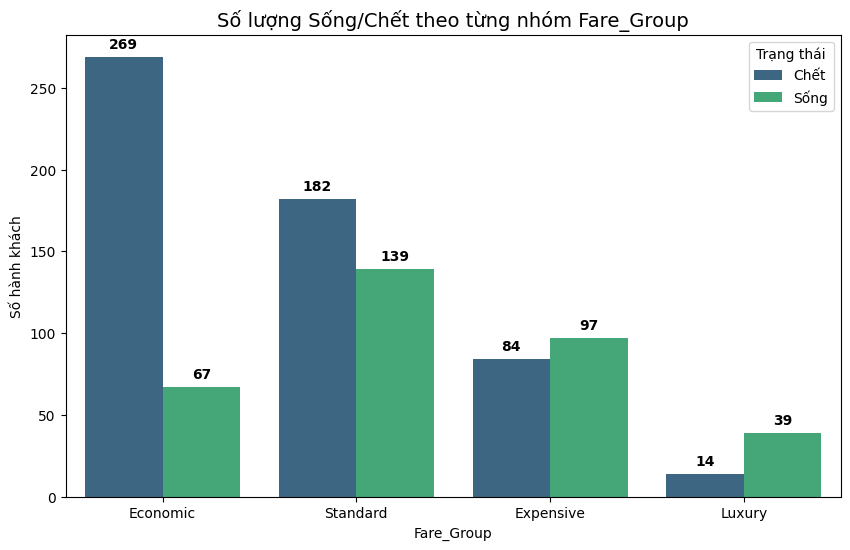

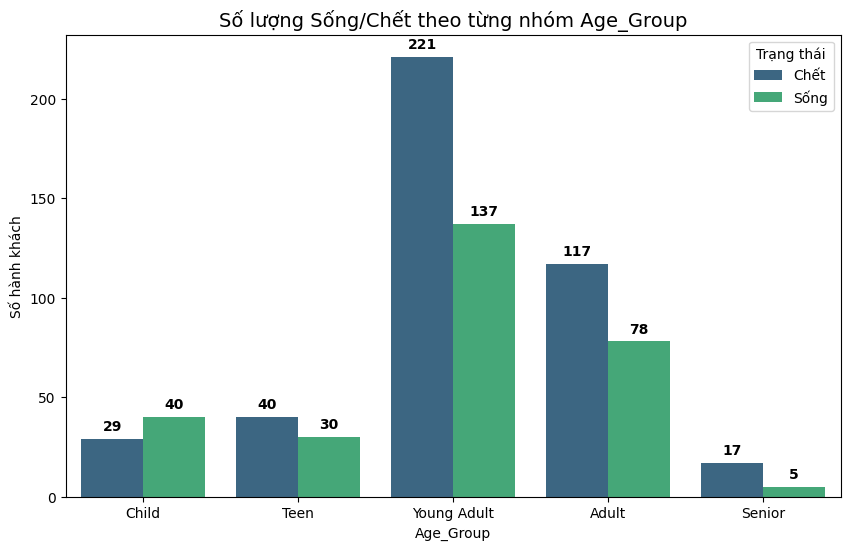

In [ ]:
def plot_binned_features(df, feature_name, target="Survived"):
    plt.figure(figsize=(10, 6))

    if feature_name == "Fare_Group":
        order = ["Economic", "Standard", "Expensive", "Luxury"]
    else:
        order = ["Child", "Teen", "Young Adult", "Adult", "Senior"]

    ax = sns.countplot(data=df, x=feature_name, hue=target, order=order, palette="viridis")

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        xytext=(0, 9),
                        textcoords='offset points',
                        fontsize=10, fontweight='bold')

    plt.title(f"Số lượng Sống/Chết theo từng nhóm {feature_name}", fontsize=14)
    plt.xlabel(feature_name)
    plt.ylabel("Số hành khách")
    plt.legend(title="Trạng thái", labels=["Chết", "Sống"])
    plt.show()

plot_binned_features(train_df, "Fare_Group")

train_df["Age_Group"] = pd.cut(
    train_df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"],
    include_lowest=True
)

plot_binned_features(train_df, "Age_Group")

NHẬN XÉT:


> Biểu đồ Fare_Group và Survived cho thấy mối quan hệ khá rõ giữa giá vé và khả năng sống sót. Ở nhóm Economic, số người không sống sót vượt trội so với số người sống sót, cho thấy hành khách mua vé rẻ có cơ hội sống thấp hơn. Khi giá vé tăng lên (Standard, Expensive), khoảng cách giữa hai nhóm dần giảm và đến nhóm Expensive thì số người sống sót bắt đầu nhiều hơn


> Ở nhóm Luxury, mặc dù số lượng hành khách ít nhưng tỷ lệ sống sót cao hơn rõ rệt. Điều này cho thấy giá vé càng cao thì khả năng sống sót càng lớn, có thể do liên quan đến hạng khoang và vị trí thuận lợi hơn để tiếp cận thuyền cứu sinh





NHẬN XÉT:


> Nhóm Child có số người sống sót nhiều hơn số không sống, cho thấy trẻ em thường được ưu tiên cứu hộ. Nhóm Teen có tỷ lệ sống và không sống khá gần nhau

> Trong khi đó, nhóm Young Adult và Adult chiếm phần lớn hành khách nhưng số người không sống sót nhiều hơn đáng kể, cho thấy người trưởng thành có tỷ lệ tử vong cao hơn


> Nhóm Senior có số lượng ít và đa phần không sống sót, có thể do hạn chế về thể lực khi sơ tán







# **7. FEATURE ENGINEERING**

7.1 TẠO CỘT FAMILY_SIZE

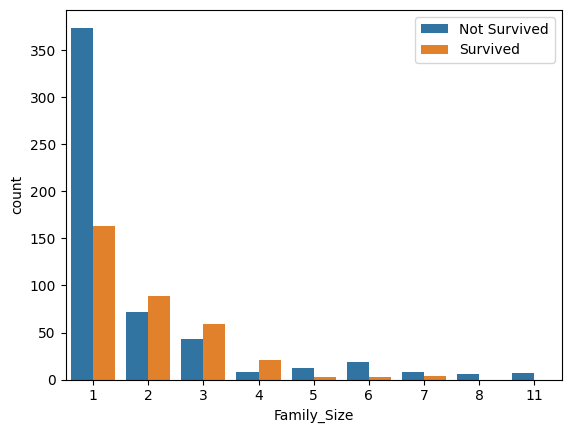

In [ ]:
train_df["Family_Size"] = train_df["SibSp"].astype("int") + train_df["Parch"].astype("int") + 1
sns.countplot(data=train_df, x="Family_Size", hue="Survived")
plt.legend(title="",labels=['Not Survived','Survived'])

NHẬN XÉT:


> Phần lớn hành khách có Family_Size = 1 (đi một mình), và trong nhóm này số người không sống sót nhiều hơn đáng kể so với số người sống sót

>  Khi Family_Size tăng lên khoảng 2–4, số người sống sót bắt đầu cao hơn hoặc gần tương đương với số người không sống sót, cho thấy những hành khách đi cùng gia đình nhỏ có xu hướng có cơ hội sống sót tốt hơn, có thể do hỗ trợ lẫn nhau trong quá trình sơ tán


> Tuy nhiên, khi Family_Size quá lớn (>= 5), số người không sống sót tăng lên rõ rệt và số người sống sót rất ít. Điều này cho thấy gia đình quá đông có thể gặp khó khăn trong việc di chuyển và lên thuyền cứu sinh kịp thời






7.2 TẠO CỘT FAMILY_CAT

<Axes: xlabel='Family_Cat', ylabel='count'>

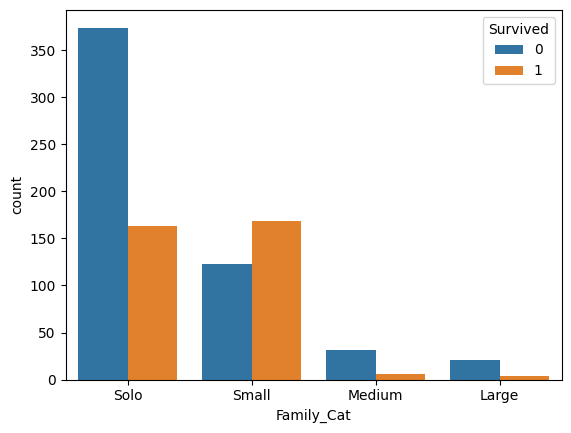

In [ ]:
train_df["Family_Cat"]= pd.cut(train_df["Family_Size"], bins=[0,1,4,6,20], labels=["Solo","Small","Medium","Large"])
sns.countplot(data=train_df, x=train_df["Family_Cat"],hue="Survived")

**Lý do tạo cột Family_Size và Family_Cat:** Việc tạo ra Family_Size và phân loại thành Family_Cat giúp mô hình nắm bắt được mối quan hệ xã hội và khả năng hỗ trợ lẫn nhau giữa các hành khách. Trong thảm họa Titanic, những người đi một mình (Solo) thường thiếu sự trợ giúp, trong khi các gia đình quá đông (Large) lại gặp khó khăn trong việc tập hợp đầy đủ thành viên để lên thuyền cứu hộ kịp lúc. Nhóm gia đình nhỏ (Small) thường có tỉ lệ sống sót cao nhất nhờ sự linh hoạt và hỗ trợ nhóm hiệu quả. Bằng cách gom nhóm này ta chuyển đổi những con số rời rạc (SibSp, Parch) thành một đặc trưng có ý nghĩa trực tiếp đến khả năng sinh tồn

7.3 TẠO CỘT HAS_CABIN

In [ ]:
# Tạo biến Has_Cabin trước khi xử lý các phần khác
train_df['Has_Cabin'] = train_df['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)
# Xóa các biến phụ dùng để kiểm chứng (Is_Cabin_Missing) nếu còn
if 'Is_Cabin_Missing' in train_df.columns:
    train_df.drop(columns=['Is_Cabin_Missing'], inplace=True)

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
 12  Fare_Group   891 non-null    category
 13  Age_Group    714 non-null    category
 14  Family_Size  891 non-null    int64   
 15  Family_Cat   891 non-null    category
 16  Has_Cabin    891 non-null    int64   
dtypes: category(6), float64(2), int64(6), object(3)
memory usage: 82.9+ KB


7.4 TẠO CỘT IS_CABIN_MISSING

In [ ]:
# Tạo cột tạm để kiểm tra: 1 nếu thiếu Cabin, 0 nếu có Cabin
train_df['Is_Cabin_Missing'] = train_df['Cabin'].isnull().astype(int)

# Thống kê tỉ lệ thiếu Cabin trên từng hạng vé
cabin_check = train_df.groupby('Pclass')['Is_Cabin_Missing'].mean() * 100
print("Tỉ lệ thiếu dữ liệu Cabin theo từng Hạng vé:")
print(cabin_check)

Tỉ lệ thiếu dữ liệu Cabin theo từng Hạng vé:
Pclass
1    18.518519
2    91.304348
3    97.556008
Name: Is_Cabin_Missing, dtype: float64


/tmp/ipykernel_370/1949630562.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cabin_check = train_df.groupby('Pclass')['Is_Cabin_Missing'].mean() * 100


**Lý do tạo cột Has_Cabin và Is_Missing_Cabin:** Ciệc tạo ra biến Has_Cabin để khai thác dấu hiệu của sự giàu có và địa vị. Dữ liệu cho thấy những hành khách có số phòng cụ thể thường thuộc Hạng nhất (Pclass 1), trong khi dữ liệu thiếu (Is_Cabin_Missing) tập trung chủ yếu ở Hạng ba. Việc sở hữu một Cabin không chỉ đại diện cho số tiền họ bỏ ra mà còn cho thấy vị trí phòng ở của họ nằm ở các khu vực tách biệt, thường gần với boong tàu và các phương tiện cứu hộ hơn so với những người ở khoang phổ thông

7.5 TẠO CỘT DECK

/tmp/ipykernel_370/1198199979.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x='Deck', y='Survived', palette='viridis')


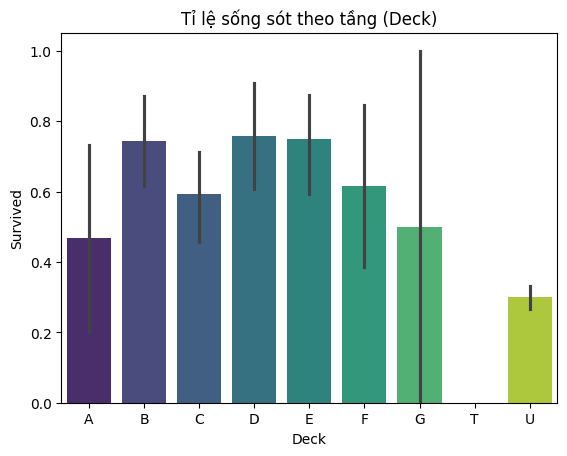

In [ ]:
# Tách lấy tầng (Deck), nếu thiếu thì điền là 'U' (Unknown)
train_df['Deck'] = train_df['Cabin'].apply(lambda x: x[0] if pd.notnull(x) else 'U')
train_df['Deck']= train_df['Deck'].astype("category")

# Sau đó vẽ thử xem tỉ lệ sống sót theo từng tầng (Deck)
sns.barplot(data=train_df, x='Deck', y='Survived', palette='viridis')
plt.title("Tỉ lệ sống sót theo tầng (Deck)")
plt.show()

**Lý do tạo cột Deck:** Việc tách ký tự đầu tiên từ mã Cabin để tạo cột Deck giúp xác định vị trí địa lý theo chiều dọc của hành khách trên tàu. Các tầng boong khác nhau (A, B, C, D...) có khoảng cách tới thuyền cứu hộ và mặt nước hoàn toàn khác nhau

### Nhóm U (Unknown)

* **Nhìn vào cột 'U' (Cột đầu tiên bên trái):** Tỉ lệ sống sót chỉ lẹt đẹt quanh mức **30%**.
* **Điểm quan trọng:** Cái vạch đen (sai số) trên đầu cột 'U' cực kỳ ngắn.
* **Dưới góc độ thống kê:** Điều này có nghĩa là mẫu của nhóm 'U' rất lớn (chiếm đa số hành khách).
* **Dưới góc độ nghiệp vụ:** Nó khẳng định lại giả thuyết của chúng ta: Những người không có số phòng (đại đa số là Hạng 3) có cơ hội sống sót thấp nhất.



### Decks B, D, E

* Các tầng **B, D, E** có tỉ lệ sống sót cao vọt (từ **70% đến 80%**).
* **Giải thích:** Đây là các tầng phía trên, gần boong tàu. Khi có sự cố, họ là những người đầu tiên tiếp cận được thuyền cứu hộ. Việc giữ lại thông tin này giúp Model nhận diện được nhóm "VIP" một cách chính xác.

### Decks G, T, A, F


* **Deck G:** Tỉ lệ sống nhìn là 50% nhưng vạch sai số chạy từ 0 lên tận 1.0! Điều này có nghĩa là nhóm này chỉ có vài ba người (mẫu quá nhỏ), không mang tính đại diện cao.
* **Deck T:** Tỉ lệ sống bằng 0. Trong thực tế lịch sử, chỉ có duy nhất 1 người ở tầng T, và người đó đã không may mắn thoát nạn.


# **8. CORRELATION MATRIX**

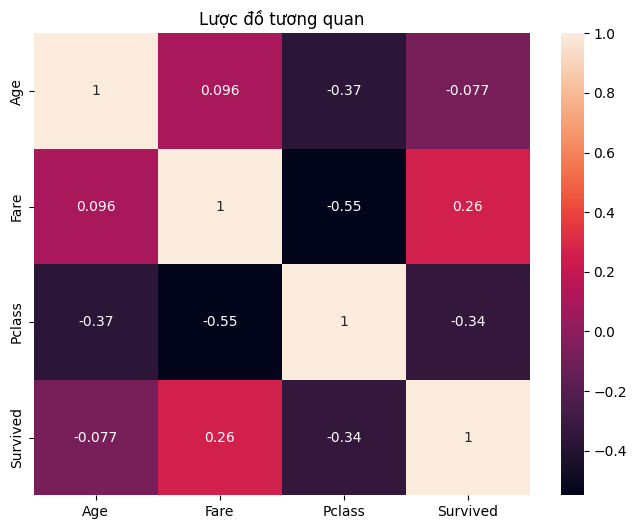

In [ ]:
num_features = ["Age", "Fare", "Pclass"]
plt.figure(figsize=(8,6))
sns.heatmap(train_df[num_features + ["Survived"]].corr(),annot=True)
plt.title("Lược đồ tương quan")
plt.show()

NHẬN XÉT:


> Biến Survived có tương quan âm với Pclass (-0.34), cho thấy khi hạng vé thấp hơn thì khả năng sống sót giảm. Điều này cho thấy hành khách ở hạng cao  thường có cơ hội sống sót tốt hơn.

> Ngoài ra, Fare có tương quan dương với Survived (0.26), nghĩa là giá vé càng cao thì khả năng sống sót có xu hướng tăng, phù hợp với việc hành khách trả vé cao thường thuộc khoang tốt hơn


> Bên cạnh đó, Fare và Pclass có tương quan âm khá mạnh (-0.55), cho thấy hạng vé càng cao thì giá vé càng đắt


> Age có tương quan âm nhẹ với Pclass (-0.33), cho thấy hành khách lớn tuổi có xu hướng ở hạng vé cao hơn một chút









#**9. Modelling**

9.1 Tack target và features


In [ ]:
X = train_df.drop(columns=["Survived"])
y = train_df["Survived"]
print(X.head())
print(y.head())

   PassengerId Pclass                                               Name  \
0            1      3                            Braund, Mr. Owen Harris   
1            2      1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2            3      3                             Heikkinen, Miss. Laina   
3            4      1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4            5      3                           Allen, Mr. William Henry   

      Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked  \
0    male  22.0      1      0         A/5 21171   7.2500   NaN        S   
1  female  38.0      1      0          PC 17599  71.2833   C85        C   
2  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S   
3  female  35.0      1      0            113803  53.1000  C123        S   
4    male  35.0      0      0            373450   8.0500   NaN        S   

  Fare_Group    Age_Group  Family_Size Family_Cat  Has_Cabin  \
0   Economic  Young Adult   

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


9.2 xây dựng mô hình dự đoán Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

Log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=10000))
])

Log_model.fit(X_train, y_train)
y_pred = Log_model.predict(X_test)

print(f"đánh giá độ chĩnh xác của mô hình {accuracy_score(y_test,y_pred)}")

đánh giá độ chĩnh xác của mô hình 0.7821229050279329


In [ ]:
#print confusion matrix
confusion = confusion_matrix(y_test,y_pred)
print(confusion)

[[88 17]
 [22 52]]


biểu đồ Confusion Matrix
TP FP
FN TN

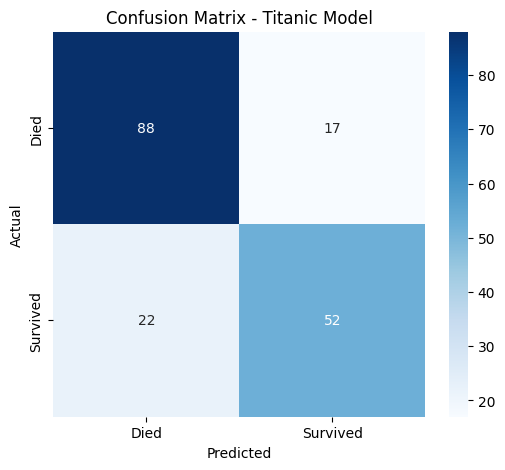

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Tính confusion matrix
confusion = confusion_matrix(y_test, y_pred)

# Vẽ heatmap
plt.figure(figsize=(6,5))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Died", "Survived"],
            yticklabels=["Died", "Survived"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Titanic Model")
plt.show()

Confusion Matrix cho thấy mô hình có khả năng phân loại khá tốt giữa hai lớp sống và không sống.

Số lượng True Positive và True Negative tương đối cao, chứng tỏ mô hình dự đoán đúng phần lớn các trường hợp.

Tuy nhiên, vẫn tồn tại một số False Positive và False Negative. Đặc biệt, False Negative thể hiện mô hình chưa nhận diện tốt một số hành khách có khả năng sống sót, điều này có thể do các đặc trưng chưa đủ mạnh hoặc dữ liệu bị mất cân bằng.

Nhìn chung, mô hình có hiệu suất tốt nhưng vẫn cần cải thiện để giảm các dự đoán sai.

Cross-validation: Đánh giá lại mô hình


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(Log_model, X, y, cv=5, scoring="accuracy")

print("Accuracy từng fold:", scores)
print("Accuracy trung bình:", scores.mean())

Accuracy từng fold: [0.79888268 0.80337079 0.78089888 0.75842697 0.79213483]
Accuracy trung bình: 0.7867428284476807


Tunning hyperparameter using gridsearchCV


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        "classifier__solver": ["liblinear"],
        "classifier__penalty": ["l1", "l2"],
       "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        "classifier__solver": ["lbfgs"],
        "classifier__penalty": ["l2"],
       "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100]
    }
]

grid = GridSearchCV(Log_model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'classifier__C': 1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
0.790692406185364


Dùng model tốt nhất

In [ ]:

best_model = grid.best_estimator_

best_model.fit(X_train, y_train)

# predict thử
y_pred_best_model = best_model.predict(X_test)

In [ ]:
print(accuracy_score(y_test,y_pred_best_model))

0.7821229050279329


Tunning hyperparameter using RandomizedSearchCV


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

param_dist = {
    "classifier__C": uniform(0.001, 100),   # random từ 0.001 → 100
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"],    # liblinear hỗ trợ cả l1 và l2
    "classifier__class_weight": [None, "balanced"]
}

random_search = RandomizedSearchCV(
    estimator=Log_model,
    param_distributions=param_dist,
    n_iter=30,              # số lần thử (tăng lên nếu muốn tốt hơn)
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best score:", random_search.best_score_)

Best params: {'classifier__C': np.float64(37.455011884736244), 'classifier__class_weight': None, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best score: 0.783669851275485


In [ ]:
best_model = random_search.best_estimator_

y_pred_best = best_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_best))

Accuracy: 0.776536312849162
Confusion matrix:
 [[87 18]
 [22 52]]


Learning Curve (Bias và Variance)

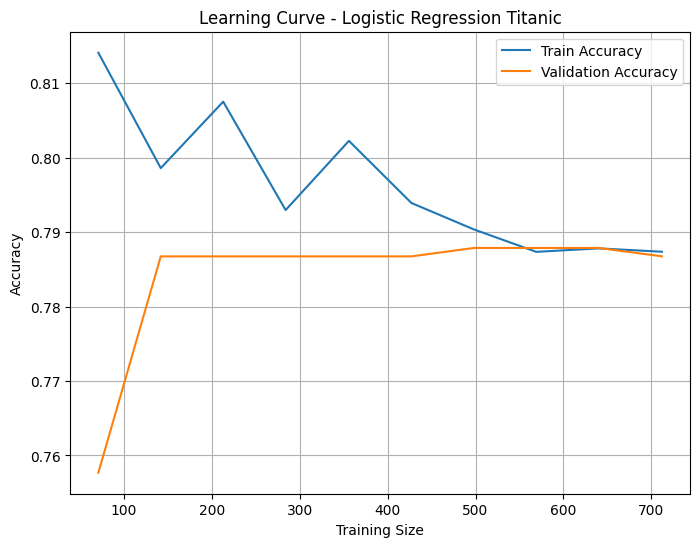

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    Log_model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# tính trung bình
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# vẽ
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label="Train Accuracy")
plt.plot(train_sizes, val_mean, label="Validation Accuracy")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Logistic Regression Titanic")
plt.legend()
plt.grid()
plt.show()

Validation Curve theo C

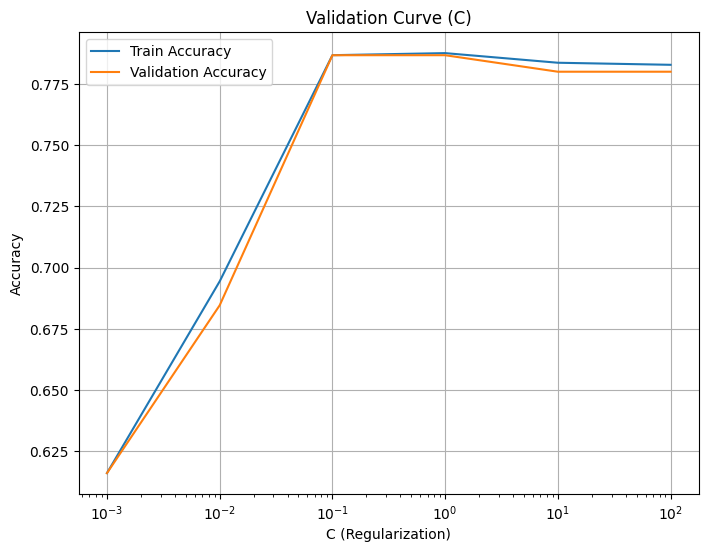

In [ ]:
from sklearn.model_selection import validation_curve

param_range = [0.001, 0.01, 0.1, 1, 10, 100]

train_scores, val_scores = validation_curve(
    Log_model,
    X,
    y,
    param_name="classifier__C",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(param_range, train_mean, label="Train Accuracy")
plt.plot(param_range, val_mean, label="Validation Accuracy")

plt.xscale("log")
plt.xlabel("C (Regularization)")
plt.ylabel("Accuracy")
plt.title("Validation Curve (C)")
plt.legend()
plt.grid()
plt.show()

9.3 Xây dựng mô hình dự đoán dùng XGBoost


In [ ]:
#XgBoost
import xgboost as xgb
from sklearn.metrics import precision_score, recall_score, f1_score
xgb_model = Pipeline(
    steps=[
    ("preprocessor", preprocessor),
    ("xgb_classifier", xgb.XGBClassifier(random_state=42, n_estimators=100))
])

xgb_model.fit(X_train,y_train)

y_pred = xgb_model.predict(X_test)



Đánh giá mô hình


In [ ]:
print(f"tỷ lệ dự đoán đúng trên tổng số mẫu dữ liệu kiểm thử. {accuracy_score(y_test,y_pred)}")
print(f"Tỷ lệ dự đoán đúng trên tổng số mẫu dữ liệu kiểm thử {precision_score(y_test,y_pred)}")
print(f"Tỷ lệ mô hình phát hiện đầy đủ các mẫu thuộc lớp thực sự {recall_score(y_test,y_pred)}")
print(f"Tổng thể của mô hình {f1_score(y_test,y_pred)}")

tỷ lệ dự đoán đúng trên tổng số mẫu dữ liệu kiểm thử. 0.7877094972067039
Tỷ lệ dự đoán đúng trên tổng số mẫu dữ liệu kiểm thử 0.7647058823529411
Tỷ lệ mô hình phát hiện đầy đủ các mẫu thuộc lớp thực sự 0.7027027027027027
Tổng thể của mô hình 0.7323943661971831


Mô hình XGBoost đạt độ chính xác tổng thể khoảng 79%, cho thấy khả năng dự đoán khá tốt. Precision đạt 76% chứng tỏ các dự đoán về hành khách sống sót tương đối đáng tin cậy. Tuy nhiên, Recall chỉ đạt 70% cho thấy mô hình vẫn bỏ sót một số trường hợp sống sót. F1-score ở mức 73.2% phản ánh sự cân bằng tương đối giữa precision và recall, nhưng vẫn còn dư địa để cải thiện khả năng phát hiện các trường hợp thuộc lớp mục tiêu.

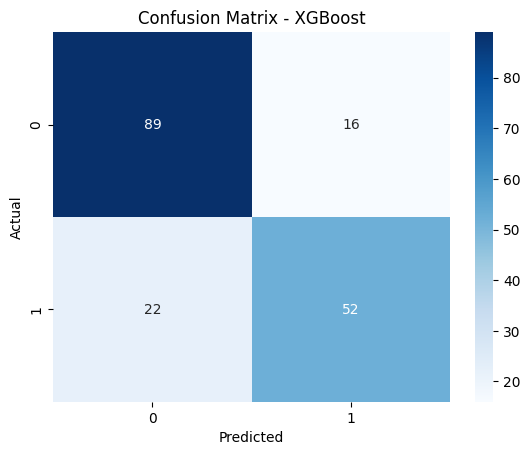

In [ ]:
xgb_cm = confusion_matrix(y_test,y_pred)

plt.figure()
sns.heatmap(xgb_cm, annot=True,fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

k-fold Cross Validation using XGBoost

In [ ]:
from xgboost import cv

params = {"objective":"binary:logistic",'colsample_bytree': 0.3,'learning_rate': 0.1, 'max_depth': 5, 'alpha': 10}

X_train_processed = preprocessor.fit_transform(X_train)

data_dmatrix = xgb.DMatrix(data=X_train_processed,label=y_train)

xgb_cv = cv(dtrain=data_dmatrix,
            params=params,
            nfold=5,
            num_boost_round=50,
            early_stopping_rounds=10,
            metrics="auc",
            as_pandas=True,
            seed=123)

ValueError: A given column is not a column of the dataframe

In [ ]:
#train model thật
best_n = len(xgb_cv) # số vòng boosting tốt nhất


xgb_model = Pipeline(
    steps=[
    ("preprocessor", preprocessor),
    ("xgb_classifier", xgb.XGBClassifier(n_estimators=best_n,learning_rate=0.1, max_depth=2))
])
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
print(f"{accuracy_score(y_test,y_pred)}")

0.7821229050279329


In [ ]:
print(f"tỷ lệ dự đoán đúng trên tổng số mẫu dữ liệu kiểm thử. {accuracy_score(y_test,y_pred)}")
print(f"Tỷ lệ dự đoán đúng trên tổng số mẫu dữ liệu kiểm thử {precision_score(y_test,y_pred)}")
print(f"Tỷ lệ mô hình phát hiện đầy đủ các mẫu thuộc lớp thực sự {recall_score(y_test,y_pred)}")
print(f"Tổng thể của mô hình {f1_score(y_test,y_pred)}")

tỷ lệ dự đoán đúng trên tổng số mẫu dữ liệu kiểm thử. 0.7821229050279329
Tỷ lệ dự đoán đúng trên tổng số mẫu dữ liệu kiểm thử 0.7464788732394366
Tỷ lệ mô hình phát hiện đầy đủ các mẫu thuộc lớp thực sự 0.7162162162162162
Tổng thể của mô hình 0.7310344827586207


vẽ confusion matrix sau khi áp dụng cross validation

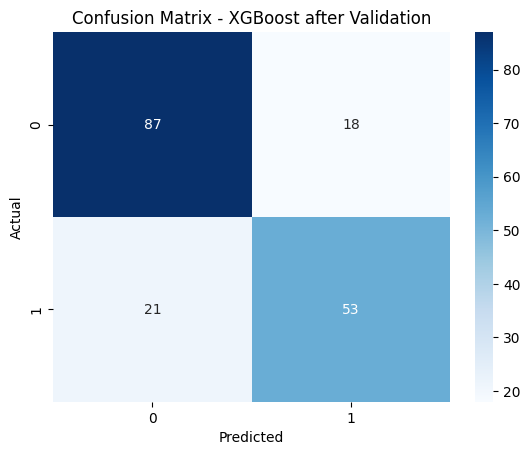

In [ ]:

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost after Validation")
plt.show()

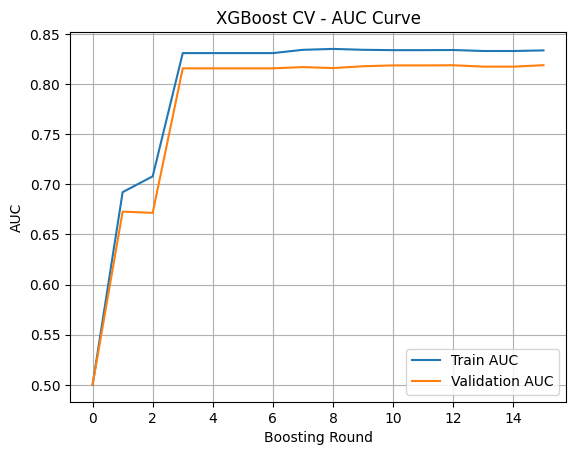

In [ ]:
plt.plot(xgb_cv["train-auc-mean"], label="Train AUC")
plt.plot(xgb_cv["test-auc-mean"], label="Validation AUC")

plt.xlabel("Boosting Round")
plt.ylabel("AUC")
plt.title("XGBoost CV - AUC Curve")
plt.legend()
plt.grid()
plt.show()

mô hình đạt khoảng 0.82 - 0.83, cho thấy khả năng phân loại khá tốt.

Tune thêm hyperparameters


*   max_depth
*   learning_rate
*   subsample
*   gamma







In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_dist = {
    "classifier__learning_rate": uniform(0.01, 0.3),
    "classifier__max_depth": randint(3, 10),
    "classifier__min_child_weight": randint(1, 10),
    "classifier__gamma": uniform(0, 0.5),
    "classifier__colsample_bytree": uniform(0.3, 0.4)
}

random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
random_search.fit(X_train, y_train)


print("Best params:", random_search.best_params_)
print("Best score:", random_search.best_score_)


ValueError: Invalid parameter 'classifier' for estimator Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('n',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('c',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                              